In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv('dataset/train.csv')

In [3]:
train.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [18]:
train.describe

<bound method NDFrame.describe of             id      Podcast_Name Episode_Title  Episode_Length_minutes  \
0            0   Mystery Matters    Episode 98                   63.84   
1            1     Joke Junction    Episode 26                  119.80   
2            2    Study Sessions    Episode 16                   73.90   
3            3    Digital Digest    Episode 45                   67.17   
4            4       Mind & Body    Episode 86                  110.51   
...        ...               ...           ...                     ...   
749995  749995      Learning Lab    Episode 25                   75.66   
749996  749996   Business Briefs    Episode 21                   75.75   
749997  749997  Lifestyle Lounge    Episode 51                   30.98   
749998  749998       Style Guide    Episode 47                  108.98   
749999  749999    Sports Central    Episode 99                   24.10   

             Genre  Host_Popularity_percentage Publication_Day  \
0       Tru

In [4]:
train.isnull().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

In [5]:
median_length = train['Episode_Length_minutes'].median()
train['Episode_Length_minutes'].fillna(median_length, inplace=True)

train['Episode_Length_minutes'] = train.groupby('Genre')['Episode_Length_minutes'].transform(lambda x: x.fillna(x.median()))


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26912\4011690343.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Episode_Length_minutes'].fillna(median_length, inplace=True)


In [6]:
train.isnull().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes              0
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

In [7]:
train['Has_Guest'] = train['Guest_Popularity_percentage'].notnull().astype(int)
train['Guest_Popularity_percentage'].fillna(0, inplace=True)
train['Guest_Popularity_percentage'] = train['Guest_Popularity_percentage'].fillna(train['Guest_Popularity_percentage'].median())


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26912\1141093092.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Guest_Popularity_percentage'].fillna(0, inplace=True)


In [8]:
train['Number_of_Ads'].fillna(train['Number_of_Ads'].mode()[0], inplace=True)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_26912\60466106.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Number_of_Ads'].fillna(train['Number_of_Ads'].mode()[0], inplace=True)


In [9]:
train.isnull().sum()

id                             0
Podcast_Name                   0
Episode_Title                  0
Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
Listening_Time_minutes         0
Has_Guest                      0
dtype: int64

In [10]:
train.duplicated().sum()

0

In [11]:
train.dtypes

id                               int64
Podcast_Name                    object
Episode_Title                   object
Episode_Length_minutes         float64
Genre                           object
Host_Popularity_percentage     float64
Publication_Day                 object
Publication_Time                object
Guest_Popularity_percentage    float64
Number_of_Ads                  float64
Episode_Sentiment               object
Listening_Time_minutes         float64
Has_Guest                        int32
dtype: object

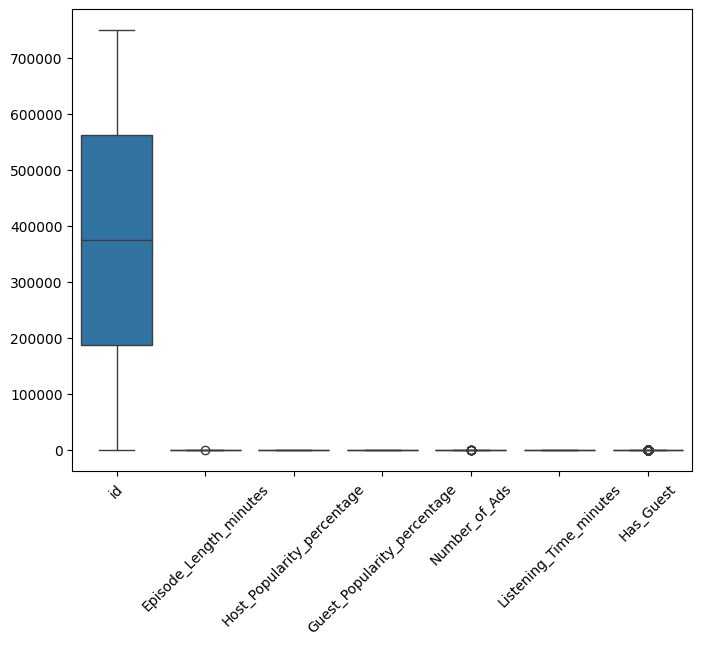

In [12]:
plt.figure(figsize=(8,6))
sns.boxplot(data=train)
plt.xticks(rotation=45)
plt.show()

In [13]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

numerical_cols = train.select_dtypes(include=['number']).columns
for col in numerical_cols:
    outliers = detect_outliers_iqr(train, col)
    print(f"Outliers in {col}: {len(outliers)}")

Outliers in id: 0
Outliers in Episode_Length_minutes: 1
Outliers in Host_Popularity_percentage: 0
Outliers in Guest_Popularity_percentage: 0
Outliers in Number_of_Ads: 9
Outliers in Listening_Time_minutes: 0
Outliers in Has_Guest: 146030


In [14]:
train['Episode_Length_minutes'].unique()

array([ 63.84      , 119.8       ,  73.9       , ..., 112.002     ,
         6.71292308,  62.16729385])

In [15]:
train['Number_of_Ads'].unique()

array([  0.  ,   2.  ,   3.  ,   1.  ,  53.37, 103.91, 103.  ,  53.42,
       103.75,  12.  , 103.25, 103.88])

In [16]:
train['Has_Guest'].unique()

array([0, 1])

In [17]:
train['Has_Guest'].value_counts()


Has_Guest
1    603970
0    146030
Name: count, dtype: int64

- Episode_Length_minutes/Number_of_Ads: The extreme values are only a few and don't disrupt the general distribution, we might keep them.

- Has_Guest: It is a binary column, consisting 0 and 1. There is no non-binary values found so we leave it as is.